In [272]:
import opendatasets as od

In [273]:
'od.download("https://www.kaggle.com/datasets/adityajn105/flickr8k")'

'od.download("https://www.kaggle.com/datasets/adityajn105/flickr8k")'

In [274]:
#os library for dealing with files 
import os
#used to store features extracted by vggnet -16 
import pickle
#To deal with string data type
import string
#To create nueral networks
import tensorflow
#Libraries for computation and visualization
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from os import listdir
from pickle import dump
from keras.applications.vgg16 import VGG16
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

In [275]:
os.getcwd()

'C:\\Users\\Infinity\\Documents\\SEM 7\\Study\\Computer Vision\\OpenCv Notebook'

In [276]:
'''
#extract features from each photo in the directory
def extract_features(directory):
	# load the model
	model = VGG16()
	# re-structure the model
	model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
	# summarize
	print(model.summary())
	# extract features from each photo
	features = dict()
	for name in listdir(directory):
		# load an image from file
		filename = directory + '/' + name
		image = load_img(filename, target_size=(224, 224))
		# convert the image pixels to a numpy array
		image = img_to_array(image)
		# reshape data for the model
		image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
		# prepare the image for the VGG model
		image = preprocess_input(image)
		# get features
		feature = model.predict(image, verbose=0)
		# get image id
		image_id = name.split('.')[0]
		# store feature
		features[image_id] = feature
		print('>%s' % name)
	return features
 
# extract features from all images
directory = "flickr8K/Images"
features = extract_features(directory)
print('Extracted Features: %d' % len(features))
# save to file
dump(features, open('features.pkl', 'wb'))
'''


'\n#extract features from each photo in the directory\ndef extract_features(directory):\n\t# load the model\n\tmodel = VGG16()\n\t# re-structure the model\n\tmodel = Model(inputs=model.inputs, outputs=model.layers[-2].output)\n\t# summarize\n\tprint(model.summary())\n\t# extract features from each photo\n\tfeatures = dict()\n\tfor name in listdir(directory):\n\t\t# load an image from file\n\t\tfilename = directory + \'/\' + name\n\t\timage = load_img(filename, target_size=(224, 224))\n\t\t# convert the image pixels to a numpy array\n\t\timage = img_to_array(image)\n\t\t# reshape data for the model\n\t\timage = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))\n\t\t# prepare the image for the VGG model\n\t\timage = preprocess_input(image)\n\t\t# get features\n\t\tfeature = model.predict(image, verbose=0)\n\t\t# get image id\n\t\timage_id = name.split(\'.\')[0]\n\t\t# store feature\n\t\tfeatures[image_id] = feature\n\t\tprint(\'>%s\' % name)\n\treturn features\n \n# extr

In [277]:
 #load doc into memory
def load_doc(filename):
    # open the file as read only
    file = open(filename, 'r')
    # read all text
    text = file.read()
    # close the file
    file.close()
    return text
 
filename = 'flickr8k/Flickr8k_text/Flickr8k.token.txt'
# load descriptions
doc = load_doc(filename)

In [278]:
# extract descriptions for images
def load_descriptions(doc):
	mapping = dict()
	# process lines
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		if len(line) < 2:
			continue
		# take the first token as the image id, the rest as the description
		image_id, image_desc = tokens[0], tokens[1:]
		# remove filename from image id
		image_id = image_id.split('.')[0]
		# convert description tokens back to string
		image_desc = ' '.join(image_desc)
		# create the list if needed
		if image_id not in mapping:
			mapping[image_id] = list()
		# store description
		mapping[image_id].append(image_desc)
	return mapping

# parse descriptions
descriptions = load_descriptions(doc)
print('Loaded: %d ' % len(descriptions))

Loaded: 8092 


In [279]:
descriptions #print all the descriptions

{'1000268201_693b08cb0e': ['A child in a pink dress is climbing up a set of stairs in an entry way .',
  'A girl going into a wooden building .',
  'A little girl climbing into a wooden playhouse .',
  'A little girl climbing the stairs to her playhouse .',
  'A little girl in a pink dress going into a wooden cabin .'],
 '1001773457_577c3a7d70': ['A black dog and a spotted dog are fighting',
  'A black dog and a tri-colored dog playing with each other on the road .',
  'A black dog and a white dog with brown spots are staring at each other in the street .',
  'Two dogs of different breeds looking at each other on the road .',
  'Two dogs on pavement moving toward each other .'],
 '1002674143_1b742ab4b8': ['A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .',
  'A little girl is sitting in front of a large painted rainbow .',
  'A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .',
  'There is a gi

In [280]:
import string
 
def clean_descriptions(descriptions):
	# prepare translation table for removing punctuation
	table = str.maketrans('', '', string.punctuation)
	for key, desc_list in descriptions.items():
		for i in range(len(desc_list)):
			desc = desc_list[i]
			# tokenize
			desc = desc.split()
			# convert to lower case
			desc = [word.lower() for word in desc]
			# remove punctuation from each token
			desc = [w.translate(table) for w in desc]
			# remove hanging 's' and 'a'
			desc = [word for word in desc if len(word)>1]
			# remove tokens with numbers in them
			desc = [word for word in desc if word.isalpha()]
			# store as string
			desc_list[i] =  ' '.join(desc)
			print(desc_list[i])
			return desc
 
# clean descriptions
cleaned = clean_descriptions(descriptions)

child in pink dress is climbing up set of stairs in an entry way


In [281]:
cleaned

['child',
 'in',
 'pink',
 'dress',
 'is',
 'climbing',
 'up',
 'set',
 'of',
 'stairs',
 'in',
 'an',
 'entry',
 'way']

In [282]:
# convert the loaded descriptions into a vocabulary of words
def to_vocabulary(descriptions):
	# build a list of all description strings
	all_desc = set()
	for key in descriptions.keys():
		[all_desc.update(d.split()) for d in descriptions[key]]
	return all_desc
 
# summarize vocabulary
vocabulary = to_vocabulary(descriptions)
print('Vocabulary Size: %d' % len(vocabulary))

Vocabulary Size: 9630


In [283]:
#Set which contains the vocabulary
print(vocabulary)

{'poster', 'her', 'leaping', 'closing', 'step', 'hand-railing', 'books', 'straddles', 'circled', 'democrat', 'rock-climbs', 'quintet', 'leader', 'Weirmeiner', 'bales', 'tugboat', 'balances', 'boarded', 'climbs', 'ten', 'orangesunset', 'workers', 'Pink', 'series', 'dusted', 'feel', 'motion', 'stiffing', 'puzzled', 'Claws', 'lighter', 'israei', 'clearing', 'packaged', 'OT', 'negotiates', 'showgirls', 'profusely', 'terrorizes', 'PitBull', 'treck', 'goofy', 'seagull', 'chandelier', 'parasail', 'skirts', 'walls', 'play-fighting', 'vandalized', 'frolic', 'piling', 'stick', 'fork', 'Runner', 'glowing', 'back', 'beach', 'tosses', 'needs', 'Peace', 'beds', 'hippie', 'holding', 'Hero', 'directs', 'preserves', 'weights', 'hundreds', 'shoppers', 'scrap', 'rasing', 'squeamish', 'eight', 'aisle', 'gingerbread', 'rabbits', 'song', 'coarse', 'any', 'stream', 'hot', 'edges', 'bulls', 'monkey', 'contained', '3-wheeler', 'astonishment', 'chained', 'cattle', 'Yellow', 'fog', 'Male', 'moutainside', 'knelt'

In [284]:
# save descriptions to file, one per line
def save_descriptions(descriptions, filename):
	lines = list()
	for key, desc_list in descriptions.items():
		for desc in desc_list:
			lines.append(key + ' ' + desc)
	data = '\n'.join(lines)
	file = open(filename, 'w')
	file.write(data)
	file.close()
 
# save descriptions
save_descriptions(descriptions, 'descriptions.txt')

In [285]:
# load doc into memory
def load_doc(filename):
	# open the file as read only
	file = open(filename, 'r')
	# read all text
	text = file.read()
	# close the file
	file.close()
	return text
 
# load a pre-defined list of photo identifiers
def load_set(filename):
	doc = load_doc(filename)
	dataset = list()
	# process line by line
	for line in doc.split('\n'):
		# skip empty lines
		if len(line) < 1:
			continue
		# get the image identifier
		identifier = line.split('.')[0]
		dataset.append(identifier)
	return set(dataset)

In [286]:
# load clean descriptions into memory
def load_clean_descriptions(filename, dataset):
	# load document
	doc = load_doc(filename)
	descriptions = dict()
	for line in doc.split('\n'):
		# split line by white space
		tokens = line.split()
		# split id from description
		image_id, image_desc = tokens[0], tokens[1:]
		# skip images not in the set
		if image_id in dataset:
			# create list
			if image_id not in descriptions:
				descriptions[image_id] = list()
			# wrap description in tokens
			desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
			# store
			descriptions[image_id].append(desc)
	return descriptions

In [287]:
# load photo features
def load_photo_features(filename, dataset):
	# load all features
	all_features = load(open(filename, 'rb'))
	# filter features
	features = {k: all_features[k] for k in dataset}
	return features

In [288]:
from pickle import load
# load training dataset (6K)

filename = 'flickr8k/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# photo features
train_features = load_photo_features('features.pkl', train)
print('Photos: train=%d' % len(train_features))

Dataset: 6000
Descriptions: train=6000
Photos: train=6000


In [289]:
train_descriptions

{'1000268201_693b08cb0e': ['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
  'startseq A girl going into a wooden building . endseq',
  'startseq A little girl climbing into a wooden playhouse . endseq',
  'startseq A little girl climbing the stairs to her playhouse . endseq',
  'startseq A little girl in a pink dress going into a wooden cabin . endseq'],
 '1001773457_577c3a7d70': ['startseq A black dog and a spotted dog are fighting endseq',
  'startseq A black dog and a tri-colored dog playing with each other on the road . endseq',
  'startseq A black dog and a white dog with brown spots are staring at each other in the street . endseq',
  'startseq Two dogs of different breeds looking at each other on the road . endseq',
  'startseq Two dogs on pavement moving toward each other . endseq'],
 '1002674143_1b742ab4b8': ['startseq A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl . endseq',
  'startseq A little 

In [290]:
train_features

{'1397923690_d3bf1f799e': array([[     4.0427,           0,      1.8623, ...,           0,      1.7489,           0]], dtype=float32),
 '2579460386_94c489028d': array([[          0,      3.0724,     0.24599, ...,           0,      2.4669,     0.60062]], dtype=float32),
 '3700554247_9824ae6f3a': array([[          0,           0,           0, ...,           0,      0.8522,           0]], dtype=float32),
 '2333584535_1eaf9baf3e': array([[          0,           0,           0, ...,           0,      0.1386,           0]], dtype=float32),
 '2840344516_8e15fe2668': array([[    0.21472,           0,           0, ...,      1.7562,      2.9041,           0]], dtype=float32),
 '3572346664_e1e6c77f11': array([[          0,           0,     0.27597, ...,           0,           0,           0]], dtype=float32),
 '3331102049_bc65cf6198': array([[          0,           0,           0, ...,      1.1387,           0,           0]], dtype=float32),
 '1481062342_d9e34366c4': array([[     1.8968,      3.2

In [291]:
from keras.preprocessing.text import Tokenizer

In [292]:
# convert a dictionary of clean descriptions to a list of descriptions
def to_lines(descriptions):
	all_desc = list()
	for key in descriptions.keys():
		[all_desc.append(d) for d in descriptions[key]]
	return all_desc
 
# fit a tokenizer for cleaned caption descriptions
def create_tokenizer(descriptions):
	lines = to_lines(descriptions)
	tokenizer = Tokenizer()
	tokenizer.fit_on_texts(lines)
	return tokenizer
 
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)

Vocabulary Size: 7378


In [293]:
# calculate the length of the description with the most words
def max_length(descriptions):
    lines = to_lines(descriptions)
    return max(len(d.split()) for d in lines)

In [294]:
descriptions_from_dict_to_list = to_lines(train_descriptions)

In [295]:
descriptions_from_dict_to_list

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq A girl going into a wooden building . endseq',
 'startseq A little girl climbing into a wooden playhouse . endseq',
 'startseq A little girl climbing the stairs to her playhouse . endseq',
 'startseq A little girl in a pink dress going into a wooden cabin . endseq',
 'startseq A black dog and a spotted dog are fighting endseq',
 'startseq A black dog and a tri-colored dog playing with each other on the road . endseq',
 'startseq A black dog and a white dog with brown spots are staring at each other in the street . endseq',
 'startseq Two dogs of different breeds looking at each other on the road . endseq',
 'startseq Two dogs on pavement moving toward each other . endseq',
 'startseq A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl . endseq',
 'startseq A little girl is sitting in front of a large painted rainbow . endseq',
 'startseq A small girl in

In [296]:
number_of_captions = len(descriptions_from_dict_to_list)

In [297]:
print(number_of_captions)

30000


In [298]:
from numpy import array
from pickle import load
from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.utils import to_categorical
from keras.utils import plot_model
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Embedding
from keras.layers import Dropout
from keras.layers import add
from keras.callbacks import ModelCheckpoint

In [299]:
# create sequences of images, input sequences and output words for an image
def create_sequences(tokenizer, max_length, desc_list, photo, vocab_size):
	X1, X2, y = list(), list(), list()
	# walk through each description for the image
	for desc in desc_list:
		# encode the sequence
		seq = tokenizer.texts_to_sequences([desc])[0]
		# split one sequence into multiple X,y pairs
		for i in range(1, len(seq)):
			# split into input and output pair
			in_seq, out_seq = seq[:i], seq[i]
			# pad input sequence
			in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
			# encode output sequence
			out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
			# store
			X1.append(photo)
			X2.append(in_seq)
			y.append(out_seq)
	return array(X1), array(X2), array(y)

In [300]:
sample_list =[]
for i in range(0,6):
    sample_list.append(descriptions_from_dict_to_list[i])

In [301]:
sample_list

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq A girl going into a wooden building . endseq',
 'startseq A little girl climbing into a wooden playhouse . endseq',
 'startseq A little girl climbing the stairs to her playhouse . endseq',
 'startseq A little girl in a pink dress going into a wooden cabin . endseq',
 'startseq A black dog and a spotted dog are fighting endseq']

In [302]:
photo = train_features['1000268201_693b08cb0e']

In [303]:
photo

array([[     2.5075,           0,           0, ...,           0,           0,           0]], dtype=float32)

In [304]:
# define the captioning model
def define_model(vocab_size, max_length):
	# feature extractor model
	inputs1 = Input(shape=(4096,))
	fe1 = Dropout(0.5)(inputs1)
	fe2 = Dense(256, activation='relu')(fe1)
	# sequence model
	inputs2 = Input(shape=(max_length,))
	se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
	se2 = Dropout(0.5)(se1)
	se3 = LSTM(256)(se2)
	# decoder model
	decoder1 = add([fe2, se3])
	decoder2 = Dense(256, activation='relu')(decoder1)
	outputs = Dense(vocab_size, activation='softmax')(decoder2)
	# tie it together [image, seq] [word]
	model = Model(inputs=[inputs1, inputs2], outputs=outputs)
	model.compile(loss='categorical_crossentropy', optimizer='adam',metrics ='accuracy')
	# summarize model
	print(model.summary())
	plot_model(model, to_file='model.png', show_shapes=True)
	return model

In [305]:
# data generator, intended to be used in a call to model.fit_generator()
def data_generator(descriptions, photos, tokenizer, max_length, vocab_size):
	# loop for ever over images
	while 1:
		for key, desc_list in descriptions.items():
			# retrieve the photo feature
			photo = photos[key][0]
			in_img, in_seq, out_word = create_sequences(tokenizer, max_length, desc_list, photo, vocab_size)
			yield [in_img, in_seq], out_word

In [306]:
# load training dataset (6K)
filename = 'flickr8k/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# photo features
train_features = load_photo_features('features.pkl', train)
print('Photos: train=%d' % len(train_features))
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)
# determine the maximum sequence length
max_length = max_length(train_descriptions)
print('Description Length: %d' % max_length)
# prepare sequences
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, train_descriptions, train_features, vocab_size)

Dataset: 6000
Descriptions: train=6000
Photos: train=6000
Vocabulary Size: 7378
Description Length: 40


In [307]:
# load test set
filename = 'flickr8k/Flickr8k_text/Flickr_8k.devImages.txt'
test = load_set(filename)
print('Dataset: %d' % len(test))
# descriptions
test_descriptions = load_clean_descriptions('descriptions.txt', test)
print('Descriptions: test=%d' % len(test_descriptions))
# photo features
test_features = load_photo_features('features.pkl', test)
print('Photos: test=%d' % len(test_features))
# prepare sequences
X1test, X2test, ytest = create_sequences(tokenizer, max_length, test_descriptions, test_features, vocab_size)

Dataset: 1000
Descriptions: test=1000
Photos: test=1000


In [308]:
generator = data_generator(train_descriptions, train_features, tokenizer, max_length, vocab_size)

In [309]:
# define the model
model = define_model(vocab_size, max_length)
# define checkpoint callback
filepath = 'model-ep{epoch:03d}-loss{loss:.3f}-val_loss{val_loss:.3f}.h5'
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

Model: "model_88"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_100 (InputLayer)         [(None, 40)]         0           []                               
                                                                                                  
 input_99 (InputLayer)          [(None, 4096)]       0           []                               
                                                                                                  
 embedding_10 (Embedding)       (None, 40, 256)      1888768     ['input_100[0][0]']              
                                                                                                  
 dropout_20 (Dropout)           (None, 4096)         0           ['input_99[0][0]']               
                                                                                           

In [310]:
'''
# train the model, run epochs manually and save after each epoch
epochs = 10
steps = len(train_descriptions)

for i in range(epochs):
   # create the data generator
   generator = data_generator(train_descriptions, train_features, tokenizer, max_length, vocab_size)
   # fit for one epoch
   model.fit_generator(generator, epochs=1, steps_per_epoch=steps, verbose=1)
   #save model
   model.save('model_' + str(i) + '.h5')
'''


"\n# train the model, run epochs manually and save after each epoch\nepochs = 10\nsteps = len(train_descriptions)\n\nfor i in range(epochs):\n   # create the data generator\n   generator = data_generator(train_descriptions, train_features, tokenizer, max_length, vocab_size)\n   # fit for one epoch\n   model.fit_generator(generator, epochs=1, steps_per_epoch=steps, verbose=1)\n   #save model\n   model.save('model_' + str(i) + '.h5')\n"

In [311]:
# map an integer to a word
def word_for_id(integer, tokenizer):
	for word, index in tokenizer.word_index.items():
		if index == integer:
			return word
	return None
import numpy as np
# generate a description for an image
def generate_desc(model, tokenizer, photo, max_length):
	# seed the generation process
	in_text = 'startseq'
	# iterate over the whole length of the sequence
	for i in range(max_length):
		# integer encode input sequence
		sequence = tokenizer.texts_to_sequences([in_text])[0]
		# pad input
		sequence = pad_sequences([sequence], maxlen=max_length)
		# predict next word
		yhat = model.predict([photo,sequence], verbose=0)
		# convert probability to integer
		yhat = np.argmax(yhat)
		# map integer to word
		word = word_for_id(yhat, tokenizer)
		# stop if we cannot map the word
		if word is None:
			break
		# append as input for generating the next word
		in_text += ' ' + word
		# stop if we predict the end of the sequence
		if word == 'endseq':
			break
	return in_text

In [312]:
from nltk.translate import bleu
from nltk.translate.bleu_score import corpus_bleu

In [313]:
# evaluate the skill of the model
def evaluate_model(model, descriptions, photos, tokenizer, max_length):
	actual, predicted = list(), list()
	# step over the whole set
	for key, desc_list in descriptions.items():
		# generate description
		yhat = generate_desc(model, tokenizer, photos[key], max_length)
		# store actual and predicted
		references = [d.split() for d in desc_list]
		actual.append(references)
		predicted.append(yhat.split())
    # calculate BLEU score
	print('BLEU-1: %f' % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
	print('BLEU-2: %f' % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
	print('BLEU-3: %f' % corpus_bleu(actual, predicted, weights=(0.3, 0.3, 0.3, 0)))
	print('BLEU-4: %f' % corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)))

In [314]:
# prepare tokenizer on train set
 # load training dataset (6K)
filename = 'flickr8k/Flickr8k_text/Flickr_8k.trainImages.txt'
train = load_set(filename)
print('Dataset: %d' % len(train))
# descriptions
train_descriptions = load_clean_descriptions('descriptions.txt', train)
print('Descriptions: train=%d' % len(train_descriptions))
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)
vocab_size = len(tokenizer.word_index) + 1
print('Vocabulary Size: %d' % vocab_size)

# determine the maximum sequence length
max_length2 = max_length(train_descriptions)
print('Description Length: %d' % max_length2)

Dataset: 6000
Descriptions: train=6000
Vocabulary Size: 7378


TypeError: 'int' object is not callable

In [ ]:
'''
# prepare test set
 
# load test set
filename = 'flickr8k/Flickr8k_text/Flickr_8k.testImages.txt'
test = load_set(filename)
print('Dataset: %d' % len(test))
# descriptions
test_descriptions = load_clean_descriptions('descriptions.txt', test)
print('Descriptions: test=%d' % len(test_descriptions))
# photo features
test_features = load_photo_features('features.pkl', test)
print('Photos: test=%d' % len(test_features))
 
# load the model
filename = 'flickr8k/model_0.h5'
model = load_model(filename)
# evaluate model
evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)
'''

In [315]:
from tensorflow.keras.preprocessing.image import load_img
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import img_to_array
from keras.models import load_model
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

In [316]:
# fit a tokenizer given caption descriptions
def create_tokenizer(descriptions):
	lines = to_lines(descriptions)
	tokenizer = Tokenizer()
	tokenizer.fit_on_texts(lines)
	return tokenizer
 
# prepare tokenizer
tokenizer = create_tokenizer(train_descriptions)

In [317]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cvzone
import math
import time

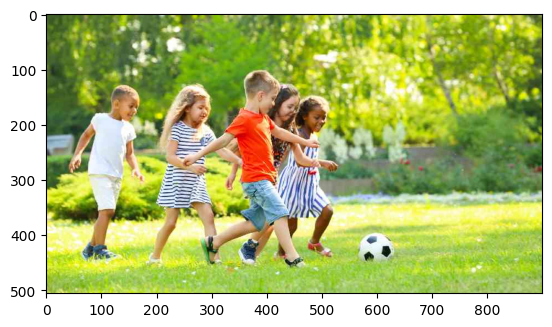

In [318]:
image = cv2.imread("children_playing.jpg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

In [319]:
model = YOLO("yolov8x.pt")

In [320]:
results = model.predict("children_playing.jpg")


image 1/1 C:\Users\Infinity\Documents\SEM 7\Study\Computer Vision\OpenCv Notebook\children_playing.jpg: 384x640 5 persons, 1 bench, 1 sports ball, 942.8ms
Speed: 0.0ms preprocess, 942.8ms inference, 10.0ms postprocess per image at shape (1, 3, 384, 640)


In [321]:
result = results[0]

In [322]:
result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
keys: ['boxes']
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58:

In [323]:
 results [0].boxes

WARNING  'Boxes.boxes' is deprecated. Use 'Boxes.data' instead.


ultralytics.engine.results.Boxes object with attributes:

boxes: tensor([[3.9499e+01, 1.2771e+02, 1.7930e+02, 4.5204e+02, 9.3917e-01, 0.0000e+00],
        [2.4639e+02, 1.0231e+02, 4.9829e+02, 4.6253e+02, 9.2019e-01, 0.0000e+00],
        [5.6558e+02, 3.9723e+02, 6.3151e+02, 4.5236e+02, 9.1228e-01, 3.2000e+01],
        [1.7983e+02, 1.2723e+02, 3.5337e+02, 4.5980e+02, 8.9809e-01, 0.0000e+00],
        [4.1275e+02, 1.4797e+02, 5.3076e+02, 4.4413e+02, 7.0332e-01, 0.0000e+00],
        [3.5151e+02, 1.4788e+02, 5.3145e+02, 4.4855e+02, 4.0604e-01, 0.0000e+00],
        [1.0854e-01, 2.1802e+02, 5.0114e+01, 2.5755e+02, 3.5052e-01, 1.3000e+01]])
cls: tensor([ 0.,  0., 32.,  0.,  0.,  0., 13.])
conf: tensor([0.9392, 0.9202, 0.9123, 0.8981, 0.7033, 0.4060, 0.3505])
data: tensor([[3.9499e+01, 1.2771e+02, 1.7930e+02, 4.5204e+02, 9.3917e-01, 0.0000e+00],
        [2.4639e+02, 1.0231e+02, 4.9829e+02, 4.6253e+02, 9.2019e-01, 0.0000e+00],
        [5.6558e+02, 3.9723e+02, 6.3151e+02, 4.5236e+02, 9.1228e-01, 3

In [324]:
len(results[0].boxes)

7

In [325]:
box = results[0].boxes
box

WARNING  'Boxes.boxes' is deprecated. Use 'Boxes.data' instead.


ultralytics.engine.results.Boxes object with attributes:

boxes: tensor([[3.9499e+01, 1.2771e+02, 1.7930e+02, 4.5204e+02, 9.3917e-01, 0.0000e+00],
        [2.4639e+02, 1.0231e+02, 4.9829e+02, 4.6253e+02, 9.2019e-01, 0.0000e+00],
        [5.6558e+02, 3.9723e+02, 6.3151e+02, 4.5236e+02, 9.1228e-01, 3.2000e+01],
        [1.7983e+02, 1.2723e+02, 3.5337e+02, 4.5980e+02, 8.9809e-01, 0.0000e+00],
        [4.1275e+02, 1.4797e+02, 5.3076e+02, 4.4413e+02, 7.0332e-01, 0.0000e+00],
        [3.5151e+02, 1.4788e+02, 5.3145e+02, 4.4855e+02, 4.0604e-01, 0.0000e+00],
        [1.0854e-01, 2.1802e+02, 5.0114e+01, 2.5755e+02, 3.5052e-01, 1.3000e+01]])
cls: tensor([ 0.,  0., 32.,  0.,  0.,  0., 13.])
conf: tensor([0.9392, 0.9202, 0.9123, 0.8981, 0.7033, 0.4060, 0.3505])
data: tensor([[3.9499e+01, 1.2771e+02, 1.7930e+02, 4.5204e+02, 9.3917e-01, 0.0000e+00],
        [2.4639e+02, 1.0231e+02, 4.9829e+02, 4.6253e+02, 9.2019e-01, 0.0000e+00],
        [5.6558e+02, 3.9723e+02, 6.3151e+02, 4.5236e+02, 9.1228e-01, 3

In [326]:
print("Object type:", box.cls)
print("Coordinates:", box.xyxy)
print("Probability:", box.conf)

Object type: tensor([ 0.,  0., 32.,  0.,  0.,  0., 13.])
Coordinates: tensor([[3.9499e+01, 1.2771e+02, 1.7930e+02, 4.5204e+02],
        [2.4639e+02, 1.0231e+02, 4.9829e+02, 4.6253e+02],
        [5.6558e+02, 3.9723e+02, 6.3151e+02, 4.5236e+02],
        [1.7983e+02, 1.2723e+02, 3.5337e+02, 4.5980e+02],
        [4.1275e+02, 1.4797e+02, 5.3076e+02, 4.4413e+02],
        [3.5151e+02, 1.4788e+02, 5.3145e+02, 4.4855e+02],
        [1.0854e-01, 2.1802e+02, 5.0114e+01, 2.5755e+02]])
Probability: tensor([0.9392, 0.9202, 0.9123, 0.8981, 0.7033, 0.4060, 0.3505])


In [327]:
for box in result.boxes:
  class_id = result.names[box.cls[0].item()]
  cords = box.xyxy[0].tolist()
  cords = [round(x) for x in cords]
  conf = round(box.conf[0].item(), 2)
  print("Object type:", class_id)
  print("Coordinates:", cords)
  print("Probability:", conf)
  print("---")

Object type: person
Coordinates: [39, 128, 179, 452]
Probability: 0.94
---
Object type: person
Coordinates: [246, 102, 498, 463]
Probability: 0.92
---
Object type: sports ball
Coordinates: [566, 397, 632, 452]
Probability: 0.91
---
Object type: person
Coordinates: [180, 127, 353, 460]
Probability: 0.9
---
Object type: person
Coordinates: [413, 148, 531, 444]
Probability: 0.7
---
Object type: person
Coordinates: [352, 148, 531, 449]
Probability: 0.41
---
Object type: bench
Coordinates: [0, 218, 50, 258]
Probability: 0.35
---


In [328]:
import os
from PIL import Image

In [329]:
# Create a directory to store cropped images
output_folder = "cropped_images"
os.makedirs(output_folder, exist_ok=True)

In [330]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)

    # Load the original image (replace "image_path.jpg" with your image's path)
    image_path = "children_playing.jpg"
    image = Image.open(image_path)

    # Extract coordinates
    x_min, y_min, x_max, y_max = cords

    # Crop the image using the coordinates
    cropped_image = image.crop((x_min, y_min, x_max, y_max))

    # Generate a filename for the cropped image
    filename = f"{class_id}_{conf}.jpg"

    # Save the cropped image to the output folder
    cropped_image.save(os.path.join(output_folder, filename))

    print(f"Cropped and saved {filename}")

print("Cropping completed.")


Cropped and saved person_0.94.jpg
Cropped and saved person_0.92.jpg
Cropped and saved sports ball_0.91.jpg
Cropped and saved person_0.9.jpg
Cropped and saved person_0.7.jpg
Cropped and saved person_0.41.jpg
Cropped and saved bench_0.35.jpg
Cropping completed.


### Display the images

In [331]:
# Set the path to the folder containing cropped images
cropped_images_folder = "cropped_images"

In [332]:
# Iterate through each image in the folder
for filename in os.listdir(cropped_images_folder):
    image_path = os.path.join(cropped_images_folder, filename)
    print(image_path)


cropped_images\bench_0.35.jpg
cropped_images\person_0.41.jpg
cropped_images\person_0.7.jpg
cropped_images\person_0.9.jpg
cropped_images\person_0.92.jpg
cropped_images\person_0.94.jpg
cropped_images\sports ball_0.91.jpg


In [333]:
# Iterate through each image in the folder
path_list=[]
for filename in os.listdir(cropped_images_folder):
    image_path = os.path.join(cropped_images_folder, filename)
    path_list.append(image_path)
path_list    

['cropped_images\\bench_0.35.jpg',
 'cropped_images\\person_0.41.jpg',
 'cropped_images\\person_0.7.jpg',
 'cropped_images\\person_0.9.jpg',
 'cropped_images\\person_0.92.jpg',
 'cropped_images\\person_0.94.jpg',
 'cropped_images\\sports ball_0.91.jpg']

In [334]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from os import listdir
from pickle import dump
from keras.applications.vgg16 import VGG16
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

In [335]:
def extract_features(filename):
    # load the model
    model = VGG16()
    # re-structure the model
    model.layers.pop()
    model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
    # load the photo
    image = load_img(filename, target_size=(224, 224))
    # convert the image pixels to a numpy array
    image = img_to_array(image)
    # reshape data for the model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # prepare the image for the VGG model
    image = preprocess_input(image)
    # get features
    feature = model.predict(image, verbose=0)
    return feature

In [336]:
import import_ipynb
from tensorflow.keras.preprocessing.image import load_img
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import img_to_array
from keras.models import load_model
from keras.applications.vgg16 import preprocess_input
from keras.models import Model

In [337]:
import ImageCaptioningWithObjD

In [338]:
%run ImageCaptioningWithObjD.ipynb import generate_desc

Loaded: 8092 
child in pink dress is climbing up set of stairs in an entry way
Vocabulary Size: 9630
{'poster', 'her', 'leaping', 'closing', 'step', 'hand-railing', 'books', 'straddles', 'circled', 'democrat', 'rock-climbs', 'quintet', 'leader', 'Weirmeiner', 'bales', 'tugboat', 'balances', 'boarded', 'climbs', 'ten', 'orangesunset', 'workers', 'Pink', 'series', 'dusted', 'feel', 'motion', 'stiffing', 'puzzled', 'Claws', 'lighter', 'israei', 'clearing', 'packaged', 'OT', 'negotiates', 'showgirls', 'profusely', 'terrorizes', 'PitBull', 'treck', 'goofy', 'seagull', 'chandelier', 'parasail', 'skirts', 'walls', 'play-fighting', 'vandalized', 'frolic', 'piling', 'stick', 'fork', 'Runner', 'glowing', 'back', 'beach', 'tosses', 'needs', 'Peace', 'beds', 'hippie', 'holding', 'Hero', 'directs', 'preserves', 'weights', 'hundreds', 'shoppers', 'scrap', 'rasing', 'squeamish', 'eight', 'aisle', 'gingerbread', 'rabbits', 'song', 'coarse', 'any', 'stream', 'hot', 'edges', 'bulls', 'monkey', 'containe

Photos: train=6000
Vocabulary Size: 7378
30000
Dataset: 6000
Descriptions: train=6000
Photos: train=6000
Vocabulary Size: 7378
Description Length: 40
Dataset: 1000
Descriptions: test=1000
Photos: test=1000
Model: "model_89"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_102 (InputLayer)         [(None, 40)]         0           []                               
                                                                                                  
 input_101 (InputLayer)         [(None, 4096)]       0           []                               
                                                                                                  
 embedding_11 (Embedding)       (None, 40, 256)      1888768     ['input_102[0][0]']              
                                                                                   

TypeError: 'int' object is not callable

TypeError: 'int' object is not callable

In [340]:
def prediction2(path_list):
    new_list=[]
    for i in path_list:
        new_list.append(i)
    return new_list
        
image_path_list = prediction2(path_list)        

In [341]:
image_path_list

['cropped_images\\bench_0.35.jpg',
 'cropped_images\\person_0.41.jpg',
 'cropped_images\\person_0.7.jpg',
 'cropped_images\\person_0.9.jpg',
 'cropped_images\\person_0.92.jpg',
 'cropped_images\\person_0.94.jpg',
 'cropped_images\\sports ball_0.91.jpg']

In [342]:
def prediction3(image_path_list):
    feature_list = []
    for i in image_path_list:
        tokenizer = create_tokenizer(train_descriptions)
        max_length = 40
        model = load_model('flickr8k/model_0.h5')  # Replace with your actual model path
        features = extract_features(i)
        feature_list.append(features)
    return feature_list
    
output2=prediction3(image_path_list)        
        

In [343]:
output2

[array([[          0,           0,           0, ...,           0,           0,     0.30233]], dtype=float32),
 array([[    0.54432,           0,           0, ...,           0,           0,      1.2682]], dtype=float32),
 array([[          0,           0,      2.2273, ...,      0.8302,           0,     0.97727]], dtype=float32),
 array([[          0,           0,     0.36558, ...,           0,           0,    0.055741]], dtype=float32),
 array([[     1.9042,           0,           0, ...,           0,           0,     0.54342]], dtype=float32),
 array([[    0.16741,           0,           0, ...,           0,           0,      1.6053]], dtype=float32),
 array([[          0,           0,           0, ...,      3.8421,           0,           0]], dtype=float32)]

In [344]:
def generate_descriptions(output2):
    for i in output2:
        tokenizer = create_tokenizer(train_descriptions)
        max_length = 40
        # Generate description
        description = generate_desc(model, tokenizer, i, max_length)
        description = ' '.join(description.split()[1:-1])
        print("Generated Caption:", description)
        print()
        
        
generate_descriptions(output2)

Generated Caption: apart apart apart apart cloak cloak cloak cloak apart cloak cloak apart cloak cloak cloak apart cloak cloak apart cloak cloak cloak apart cloak cloak apart cloak cloak cloak apart cloak cloak apart cloak cloak cloak apart cloak cloak

Generated Caption: sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds sleds

Generated Caption: dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons dragons

Generated Caption: com com com com com com com com com com com com com com com com com com com com com com com com com com com com com com com com com com com c

In [345]:
def prediction(cropped_images_folder):
    i = 0
    for filename in os.listdir(cropped_images_folder):
        image_path = os.path.join(cropped_images_folder, filename)
        # Load and prepare the tokenizer and model for caption generation
        tokenizer = create_tokenizer(train_descriptions)
        max_length = 40
        model = load_model('flickr8k/model_0.h5')  # Replace with your actual model path
        features = extract_features(image_path)
        i=i+1
        # Generate description
        description = generate_desc(model, tokenizer, photo, max_length)
        description = ' '.join(description.split()[1:-1])
        print("Generated Caption:", description)
        print()
    print(i)

In [346]:
cropped_images_folder = "cropped_images"
extracted_features = prediction(cropped_images_folder)

Generated Caption: a man in a red shirt is sitting on a street

Generated Caption: a man in a red shirt is sitting on a street

Generated Caption: a man in a red shirt is sitting on a street

Generated Caption: a man in a red shirt is sitting on a street

Generated Caption: a man in a red shirt is sitting on a street

Generated Caption: a man in a red shirt is sitting on a street

Generated Caption: a man in a red shirt is sitting on a street

7


In [347]:
def display_image(path):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
    # Display the original image
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

Generated Caption: a man is playing in the water


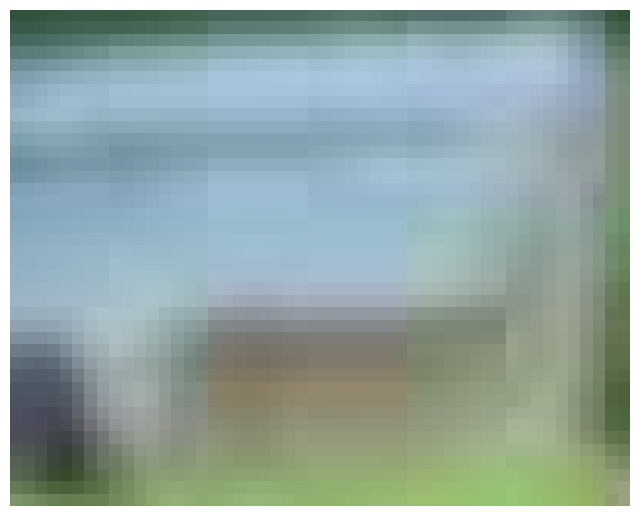


Generated Caption: a young boy in a red shirt is playing in a field


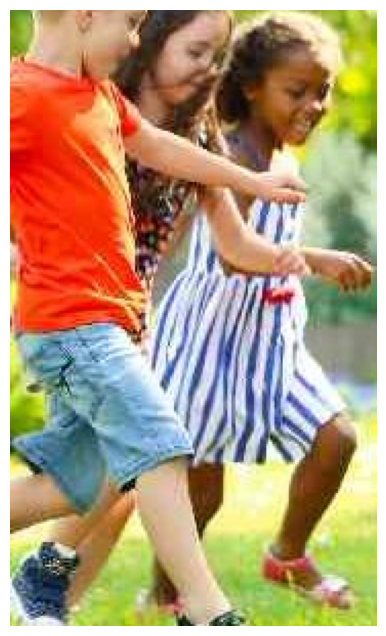


Generated Caption: a boy in a red shirt is playing in the water


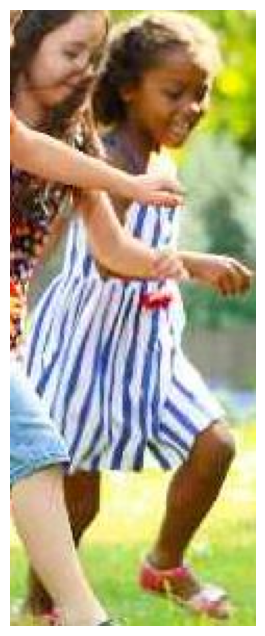


Generated Caption: a young boy in a red shirt is sitting on a field


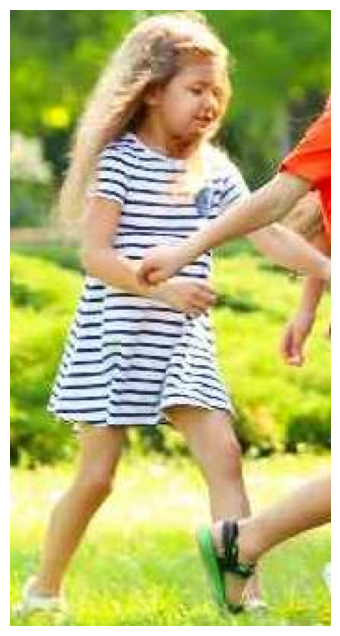


Generated Caption: a young boy in a red shirt is playing in a field


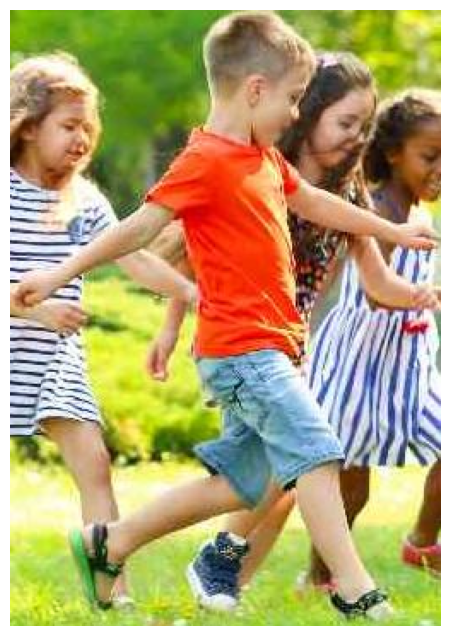


Generated Caption: a young boy in a red shirt is standing on a street


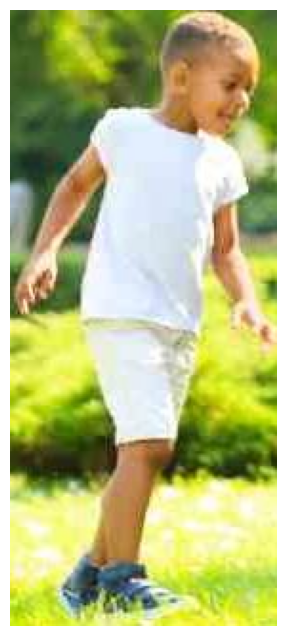


Generated Caption: a dog is running through the water


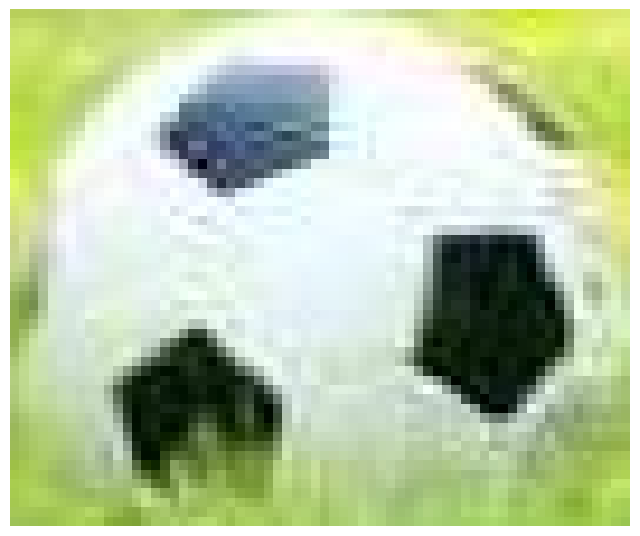

In [348]:
def prediction3(image_path_list):
    for i in image_path_list:
        # Load and prepare the tokenizer and model for caption generation
        tokenizer = create_tokenizer(train_descriptions)
        max_length = 40
        model = load_model('flickr8k/model_0.h5')  # Replace with your actual model path

        # Extract features from the image
        photo = extract_features(i)

        # Generate description
        description = generate_desc(model, tokenizer, photo, max_length)
        description = ' '.join(description.split()[1:-1])
        print("Generated Caption:", description)
        display_image(i)
        print()

prediction3(image_path_list)

1.The model should be trained for more accurate results
2.The image size of the cropped image looses the information as the image is blurred,either the image needs to be enhanced or it should be kept of the same size,in this case the transfer learning nueral network should be changed as not all cropped images have same size or the cropped image should be padded with a white background so that the context of cropped image can be restored as it will not get blur.

## Trying to put white background behind cropped images

In [363]:
from PIL import Image

In [364]:
# Load your image
image_path = "cropped_images\\sports ball_0.91.jpg"
foreground = Image.open(image_path)

In [365]:
# Define the dimensions of the white background
background_width = 224
background_height = 224
background = Image.new('RGB', (background_width, background_height), (255, 255, 255))

# Calculate the position to center the foreground image on the background
x_offset = (background_width - foreground.width) // 2
y_offset = (background_height - foreground.height) // 2

# Paste the foreground image onto the background at the calculated position
background.paste(foreground, (x_offset, y_offset))

# Save the result
output_path = "image_on_white_background.jpg"
background.save(output_path)

print("Image placed on white background and saved.")

Image placed on white background and saved.


In [366]:
def generate_description_obj(path):
    # Load the image using OpenCV
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

    # Display the original image
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    # Load and prepare the tokenizer and model for caption generation
    tokenizer = create_tokenizer(train_descriptions)
    max_length = 40
    model = load_model('flickr8k/model_0.h5')  # Replace with your actual model path

    # Extract features from the image
    photo = extract_features(path)

    # Generate description
    description = generate_desc(model, tokenizer, photo, max_length)
    description = ' '.join(description.split()[1:-1])
    print("Generated Caption:", description)
    print()


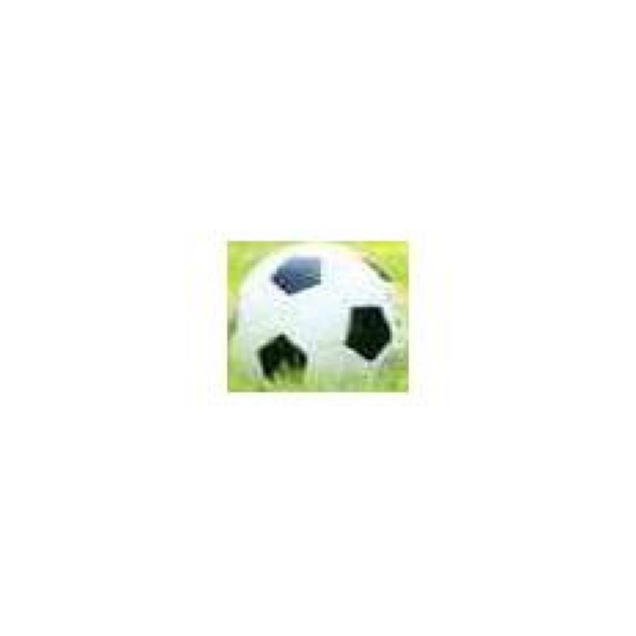

Generated Caption: a young boy in a red shirt is playing in the water



In [368]:
generate_description_obj('image_on_white_background.jpg')

The results are far better than with the white background as the image blurring is less than the previous method where direct images were taken.Select a extra high definition image for the model.
Last Edit: 03/08/2023

Train Model First